---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 13. Довга лінія</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Довга лінія</li>
  <li>Параметри довгої лінії та їх фізичний зміст</li>
  <li>Моделювання однорідної лінії ланцюговою схемою</li>
  <li>Телеграфне рівняння</li>
  <li>Рухома хвиля. Пряма і зворотна хвилі</li>
  <li>Умова для лінії, що не спотворює (умова Хевісайда)</li>
  <li>Лінія без втрат</li>
  <li>Розв'язок телеграфних рівнянь для гармонічного сигналу</li>
  <li>Вхідний опір лінії</li>
  <li>Режими роботи лінії: біжуча, стояча та змішана хвилі</li>
  <li>Відрізки лінії як реактивні елементи. Чвертьхвильовий трансформатор</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 13 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Довга лінія](#transmission-line)
    * [Параметри довгої лінії та їх фізичний зміст](#transmission-line-interactive)
    * [Моделювання однорідної лінії ланцюговою схемою](#line-ladder-model)
    * [Телеграфне рівняння](#telegraph-equation)
    * [Рухома хвиля. Пряма і зворотна хвилі](#traveling-wave)
    * [Умова для лінії, що не спотворює (умова Хевісайда)](#distortionless-line)
    * [Лінія без втрат](#lossless-line)
    * [Розв'язок телеграфних рівнянь для гармонічного сигналу](#line-phasor-solution)
    * [Вхідний опір лінії](#line-input-impedance)
    * [Режими роботи лінії: біжуча, стояча та змішана хвилі](#line-modes)
    * [Відрізки лінії як реактивні елементи. Чвертьхвильовий трансформатор](#line-stubs)
    * [🔬 Інтерактивно: вхідний опір відрізка лінії](#line-zin-interactive)
    * [⚙️ PySpice: відбиття імпульсу в лінії. Рефлектометрія](#line-tdr)
* [📌 Підсумок теми](#topic-summary)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

## Довга лінія <a class="anchor" id="transmission-line"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати, коли коло слід розглядати як лінію з розподіленими параметрами
> - Записувати телеграфні рівняння та їх розв'язок у вигляді прямої і зворотної хвиль
> - Обчислювати хвильовий опір, коефіцієнт поширення, коефіцієнт відбиття та КСХ
> - Розраховувати вхідний опір відрізка лінії та використовувати відрізки як реактивні елементи й трансформатори опорів
> - Визначати місце і характер неоднорідності в кабелі за відбитим імпульсом

</div>

---

У математиці, фізиці та інженерії, поняття **довгих ліній** є ключовим для розуміння різноманітних фізичних явищ та їх моделювання. Довгі лінії - це електричні елементи зі значною довжиною у порівнянні з довжиною хвиль, які поширюються в них.

### Основні аспекти

1. **Довга лінія** - це електричний елемент, що виявляє значний вплив на передачу електричних сигналів через нього. Її довжина порівняно велика порівняно з довжиною хвиль у передаваному сигналі. Це може бути кабель, провід або структура, яка здатна передавати сигнали.

2. **Розповсюдження сигналів**: Довгі лінії мають здатність передавати електричні сигнали на великі відстані без помітних спотворень. Це дозволяє використовувати їх у телекомунікаційних мережах, системах передачі даних, а також у системах електропередачі.

3. **Характеристичний імпеданс**: Кожна довга лінія має характеристичний імпеданс ($Z_0$), що визначається властивостями самої лінії. Він відіграє важливу роль у визначенні передачі сигналів через лінію та може бути обчислений за допомогою спеціальних формул.

    Формула для характеристичного імпедансу:
    $$ Z_0 = \sqrt{\frac{R + j\omega L}{G + j\omega C}} $$
    
     Де:
    - $R$ - опір на одиницю довжини лінії,
    - $L$ - індуктивність на одиницю довжини лінії,
    - $G$ - провідність на одиницю довжини лінії,
    - $C$ - ємність на одиницю довжини лінії,
    - $\omega$ - кругова частота сигналу.

4. **Розподіл параметрів**: Довгі лінії характеризуються розподілом параметрів, таких як імпеданс, індуктивність та ємність, вздовж їх довжини. Цей розподіл може бути змінним або сталим в залежності від характеру лінії та її конструкції.

5. **Реакція на сигнали**: Довгі лінії виявляють реакцію на різноманітні сигнали, що проходять через них. Ця реакція може включати в себе затримку сигналу, зміну амплітуди та спотворення хвильової форми. Розуміння цих ефектів дозволяє інженерам ефективно проектувати та використовувати довгі лінії у різних системах.

### Важливість у практиці

Довгі лінії мають широкі застосування у різних галузях:

- **Телекомунікаційні системи**: Вони використовуються для передачі даних у телефонних мережах, Інтернеті, телевізійних та радіомовних системах.

- **Електропередача**: Довгі лінії використовуються для передачі електроенергії від джерела до споживача.

- **Електроніка**: У мікроелектроніці вони використовуються для передачі сигналів між різними частинами електронних пристроїв.

- **Мережі передачі даних**: Вони є основою для створення мереж передачі даних, які використовуються у бізнесі та особистому житті.

- **Радіокомунікація**: У бездротових системах зв'язку довгі лінії використовуються для передачі радіосигналів на великі відстані.


---
### Параметри довгої лінії та їх фізичний зміст <a class="anchor" id="transmission-line-interactive"></a>

| Параметр | Позначення | Одиниця | Фізичний зміст |
|----------|-----------|---------|----------------|
| Погонний опір | $R'$ | Ом/м | Активні втрати провідника |
| Погонна індуктивність | $L'$ | Гн/м | Магнітна енергія навколо лінії |
| Погонна провідність | $G'$ | См/м | Втрати в діелектрику між провідниками |
| Погонна ємність | $C'$ | Ф/м | Електрична енергія між провідниками |

**Характеристичний імпеданс (хвильовий опір):**
$$Z_0 = \sqrt{\frac{R' + j\omega L'}{G' + j\omega C'}}$$
При малих втратах ($R' \ll \omega L'$, $G' \ll \omega C'$): $Z_0 \approx \sqrt{L'/C'}$

**Коефіцієнт поширення:**
$$\gamma = \alpha + j\beta = \sqrt{(R' + j\omega L')(G' + j\omega C')}$$
- $\alpha$ — коефіцієнт загасання (Нп/м)
- $\beta = \omega/v_{ph}$ — коефіцієнт фази, $v_{ph} = 1/\sqrt{L'C'}$ — фазова швидкість

**Коефіцієнт відбиття:**
$$\Gamma = \frac{Z_L - Z_0}{Z_L + Z_0}$$
- $\Gamma = 0$ при $Z_L = Z_0$ — узгоджений режим (максимальна передача потужності)
- $\Gamma = -1$ при $Z_L = 0$ (КЗ) — повне відбиття з інверсією
- $\Gamma = +1$ при $Z_L = \infty$ (розрив) — повне відбиття без інверсії

In [2]:
# Інтерактивна довга лінія: розподіл напруги вздовж лінії
def transmission_line_interactive(Z0=50.0, ZL=75.0, f_MHz=100.0, length_m=2.0, alpha_dB_m=0.0):
    c0 = 3e8  # швидкість світла
    f = f_MHz * 1e6
    lam = c0 / f
    beta = 2 * np.pi / lam  # рад/м
    alpha = alpha_dB_m / (20 * np.log10(np.e))  # дБ/м -> Нп/м
    gamma = alpha + 1j * beta

    Gamma_L = (ZL - Z0) / (ZL + Z0)

    x_vals = np.linspace(0, length_m, 500)  # від джерела до навантаження
    # у точці x від джерела; l = length − x — відстань до навантаження
    l_vals = length_m - x_vals
    V_fwd = np.exp(-gamma * x_vals)
    V_bwd = Gamma_L * np.exp(-gamma * (2*length_m - x_vals))
    V_total = V_fwd + V_bwd

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(x_vals, np.abs(V_total), '#2196F3', label='|V(x)|')
    axes[0].plot(x_vals, np.abs(V_fwd), '#4CAF50', ls='--', lw=1.5, label='Пряма хвиля')
    axes[0].plot(x_vals, np.abs(V_bwd), '#F44336', ls='--', lw=1.5, label='Відбита хвиля')
    axes[0].set_xlabel('x, м (від джерела)')
    axes[0].set_ylabel('Відносна амплітуда |V|')
    axes[0].set_title(f'КСХ (VSWR) = {(1+abs(Gamma_L))/(1-abs(Gamma_L)):.2f}')
    axes[0].legend()

    # розподіл амплітуди (КСХ) вздовж лінії
    vswr = np.abs(V_total)
    axes[1].plot(x_vals, 20*np.log10(np.abs(V_total)+1e-12), '#FF9800')
    axes[1].set_xlabel('x, м'); axes[1].set_ylabel('|V|, дБ')
    axes[1].set_title('Розподіл напруги (дБ)')

    plt.suptitle(f'Z0={Z0} Ом, ZL={ZL} Ом, f={f_MHz} МГц | '
                 f'Gamma={Gamma_L:.3f}, KCX={(1+abs(Gamma_L))/(max(1-abs(Gamma_L),1e-6)):.2f}',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'Коефіцієнт відбиття: Gamma = {Gamma_L:.3f}')
    print(f'КСХ (VSWR) = {(1+abs(Gamma_L))/max(1-abs(Gamma_L),1e-6):.3f}')
    print(f'Довжина хвилі: lambda = {lam*100:.2f} см')
    print(f'Відношення l/lambda = {length_m/lam:.3f}')

interact(transmission_line_interactive,
         Z0=widgets.FloatSlider(min=10, max=300, step=5, value=50, description='Z0 (Ом)'),
         ZL=widgets.FloatSlider(min=0, max=500, step=5, value=75, description='ZL (Ом)'),
         f_MHz=widgets.FloatSlider(min=10, max=3000, step=10, value=100, description='f (МГц)'),
         length_m=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=2.0, description='L (м)'),
         alpha_dB_m=widgets.FloatSlider(min=0, max=1, step=0.01, value=0, description='Затух. (дБ/м)'))

interactive(children=(FloatSlider(value=50.0, description='Z0 (Ом)', max=300.0, min=10.0, step=5.0), FloatSlid…

<function __main__.transmission_line_interactive(Z0=50.0, ZL=75.0, f_MHz=100.0, length_m=2.0, alpha_dB_m=0.0)>

---
### Моделювання однорідної лінії ланцюговою схемою <a class="anchor" id="line-ladder-model"></a>

Однорідну довгу лінію моделюють, подумки розбивши її на нескінченно малі відрізки довжини $\Delta x$ і замінивши кожен відрізок **зосередженою Г-подібною ланкою** з погонними параметрами:

- поздовжня вітка: $R'\Delta x$ (опір) послідовно з $L'\Delta x$ (індуктивність);
- поперечна вітка: $G'\Delta x$ (провідність) паралельно з $C'\Delta x$ (ємність).

Каскадне (ланцюгове) з'єднання $N$ таких однакових ланок при $\Delta x = l/N \to 0$ (і, відповідно, $N\to\infty$) наближає лінію довжини $l$ зі скінченною похибкою, що прямує до нуля.


Побудуємо ланцюгову модель лінії з кількох Г-подібних ланок:

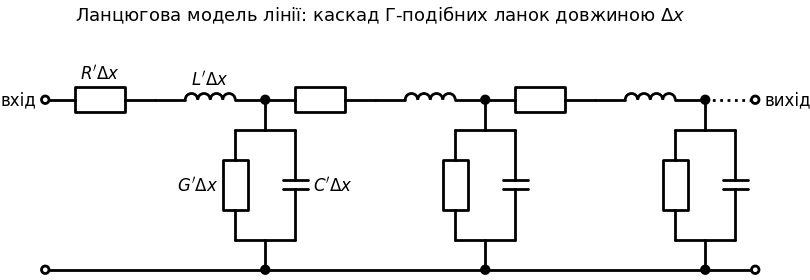

In [3]:
# Schemdraw: моделювання лінії ланцюговою (драбинчастою) схемою з Г-подібних ланок
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.2) as d:
        inp = d.add(elm.Dot(open=True).label('вхід', loc='left'))
        x0 = inp.center[0]
        for k in range(3):
            d.add(elm.Resistor().right().label("$R'\\Delta x$" if k == 0 else ''))
            d.add(elm.Inductor().right().label("$L'\\Delta x$" if k == 0 else ''))
            node = d.add(elm.Dot())
            d.push()
            d.add(elm.Line().down(0.6))
            d.add(elm.Line().left(0.6))
            d.add(elm.Resistor().down(2.2).label("$G'\\Delta x$" if k == 0 else '', loc='top'))
            d.add(elm.Line().right(0.6))
            d.add(elm.Line().at((node.center[0], node.center[1] - 0.6)).right(0.6))
            d.add(elm.Capacitor().down(2.2).label("$C'\\Delta x$" if k == 0 else '', loc='bottom'))
            d.add(elm.Line().left(0.6))
            d.add(elm.Line().down(0.6))
            d.add(elm.Dot())
            d.pop()
        d.add(elm.Line().right(1).linestyle(':'))
        d.add(elm.Dot(open=True).label('вихід', loc='right'))
        y0 = node.center[1] - 3.4
        d.add(elm.Line().at((x0, y0)).right().tox(node.center[0] + 1))
        d.add(elm.Dot(open=True).at((x0, y0)))
        d.add(elm.Dot(open=True).at((node.center[0] + 1, y0)))
        d.add(elm.Label().at((node.center[0] / 2, 1.6)).label(
            'Ланцюгова модель лінії: каскад Г-подібних ланок довжиною $\\Delta x$', fontsize=13))
else:
    print('Встановіть schemdraw: pip install schemdraw')

Запишемо закони Кірхгофа для однієї ланки між координатами $x$ і $x+\Delta x$:

$$v(x+\Delta x,t)-v(x,t) = -\Delta x\left[R' i(x,t) + L'\frac{\partial i}{\partial t}\right]$$

$$i(x+\Delta x,t)-i(x,t) = -\Delta x\left[G' v(x+\Delta x,t) + C'\frac{\partial v}{\partial t}\right]$$

Поділимо обидві частини на $\Delta x$ і перейдемо до границі $\Delta x\to0$ — різницеві відношення стають частинними похідними за координатою, і виходять саме **телеграфні рівняння**, наведені нижче:

$$\frac{\partial v}{\partial x} = -R'i-L'\frac{\partial i}{\partial t}, \qquad \frac{\partial i}{\partial x} = -G'v-C'\frac{\partial v}{\partial t}$$

Таким чином, телеграфні рівняння — це граничний випадок ланцюгової схеми при нескінченно малому кроці розбиття, а сама ланцюгова схема — зручна модель для чисельного (SPICE-подібного) моделювання лінії скінченним числом елементів.


### Телеграфне рівняння <a class="anchor" id="telegraph-equation"></a>

Телеграфне рівняння

$$ 
\begin{cases} 
\cfrac{\partial}{\partial x} V(x,t) = -L \cfrac{\partial}{\partial t} I(x,t)- R I(x,t) \\
\cfrac{\partial}{\partial x} I(x,t) = -C \cfrac{\partial}{\partial t} V(x,t)- G V(x,t)
\end{cases}$$

---
### Рухома хвиля. Пряма і зворотна хвилі <a class="anchor" id="traveling-wave"></a>

Для **лінії без втрат** ($R'=G'=0$, див. нижче) телеграфні рівняння зводяться до одного хвильового рівняння відносно напруги (аналогічно для струму):

$$\frac{\partial^2 v}{\partial x^2} = L'C'\frac{\partial^2 v}{\partial t^2}$$

Загальний розв'язок цього рівняння (розв'язок Д'Аламбера) має вигляд суми двох **рухомих хвиль**:

$$v(x,t) = \underbrace{f_1\!\left(t-\dfrac{x}{v_{ph}}\right)}_{\text{пряма хвиля}} + \underbrace{f_2\!\left(t+\dfrac{x}{v_{ph}}\right)}_{\text{зворотна хвиля}}, \qquad v_{ph}=\frac{1}{\sqrt{L'C'}}$$

- **Пряма хвиля** $f_1$ — довільна за формою функція, що переміщується від джерела до навантаження (у бік зростання $x$) зі швидкістю $v_{ph}$ без зміни форми — саме тому вона є функцією єдиної комбінованої змінної $t-x/v_{ph}$.
- **Зворотна хвиля** $f_2$ — функція, що рухається у протилежному напрямку (від навантаження до джерела); виникає внаслідок **відбиття** прямої хвилі від навантаження, якщо воно не узгоджене з хвильовим опором лінії ($Z_L\ne Z_0$, див. коефіцієнт відбиття $\Gamma$ вище).

Відповідний струм пов'язаний з хвилями напруги через характеристичний опір $Z_0$ (пряма й зворотна хвилі струму мають протилежний знак, бо рухаються у протилежних напрямках):

$$i(x,t) = \frac{1}{Z_0}\left[f_1\!\left(t-\frac{x}{v_{ph}}\right) - f_2\!\left(t+\frac{x}{v_{ph}}\right)\right]$$

У точці навантаження повна напруга й струм — це сума прямої та зворотної складових; саме такий запис (`V_fwd`, `V_bwd`) використано в інтерактивному розрахунку вище.


### Умова для лінії, що не спотворює (умова Хевісайда) <a class="anchor" id="distortionless-line"></a>

У загальному випадку коефіцієнт загасання $\alpha(\omega)$ і фазова швидкість $v_{ph}(\omega)=\omega/\beta(\omega)$ залежать від частоти — різні гармонічні складові сигналу загасають і затримуються по-різному, тому форма сигналу на виході спотворюється (явище **дисперсії**).

**Олівер Хевісайд** показав, що спотворення відсутнє, якщо виконується умова:

$$\frac{R'}{L'} = \frac{G'}{C'} \qquad\Longleftrightarrow\qquad R'C' = L'G'$$

За цієї умови коефіцієнт загасання і фазова швидкість **не залежать від частоти**:

$$\alpha = R'\sqrt{\frac{C'}{L'}} = \text{const}(\omega), \qquad v_{ph}=\frac{1}{\sqrt{L'C'}} = \text{const}(\omega)$$

тобто всі частотні складові сигналу однаково послаблюються й затримуються — сигнал на виході є точною (лише масштабованою й затриманою) копією вхідного, без спотворення форми. На практиці для кабельних ліній зазвичай $L'/R' \ll C'/G'$, тому історично для наближення до умови Хевісайда в лінії штучно збільшували погонну індуктивність, вмикаючи через певні відстані котушки навантаження (**котушки Пупіна**).

### Лінія без втрат <a class="anchor" id="lossless-line"></a>

**Лінія без втрат** — окремий (ідеалізований) випадок, коли $R'=0$ і $G'=0$ (немає ані активних втрат у провіднику, ані витоку в діелектрику). Умова Хевісайда при цьому виконується тривіально ($0=0$), тобто лінія без втрат автоматично є лінією, що не спотворює:

$$Z_0=\sqrt{\frac{L'}{C'}} \;\text{(дійсний, не залежить від }\omega),\qquad \gamma=j\beta=j\omega\sqrt{L'C'} \;(\alpha=0),\qquad v_{ph}=\frac{1}{\sqrt{L'C'}}$$

Це наближення добре працює для коротких високочастотних ліній (короткі відрізки коаксіального кабелю, мікросмужкові лінії на платі), де активні втрати за час проходження сигналу нехтовно малі.


Анімація поширення сигналу вздовж довгої лінії: оберіть амплітуду та форму вхідного сигналу (модель побудовано на основі [TransmissionLine](https://github.com/ClecioJung/TransmissionLine)).

In [4]:
# За основу взято
# https://github.com/ClecioJung/TransmissionLine/blob/main/TransmissionLine.m

#import numpy as np
#import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
#from scipy.signal import sawtooth, square


def g(V_in_sb, Signal_sb):
    # параметри лінії
    R = 45.3e-3  # Ом/м
    G = 0  # См/м (у каталозі не вказано)
    L = 0.205e-6  # H/m
    C = 182e-13  # F/m
    Z = np.sqrt(L / C)  # Ом
    vel = 1 / np.sqrt(L * C)  # m/s
    
    # опір навантаження
    Rl = 10  # Ом
    
    # генератор сигналу довільної форми
    Rg = 50  # Ом
    Ton = 10e-9  # s
    Toff = 110e-9  # s
    Vamp = 10  # V
    fg = 10e6  # Hz
    
    # тип сигналу генератора
    # варіанти: 'p' — імпульс, 's' — синусоїда, 't' — трикутник, 'q' — меандр

    if Signal_sb == 1:
        signal = 'p'
    elif Signal_sb == 2:
        signal = 's'
    elif Signal_sb == 3:
        signal = 't'
    else:
        signal = 'q'

    # метод скінченних різниць
    # варіанти: 'a' — вперед, 'r' — назад, 'c' — центрована
    finiteDiff = 'c'
    
    # метод моделювання: 'e' — явний, 'i' — неявний
    method = 'i'
    
    # інтервали моделювання
    dt = 1e-10  # s
    t0 = 0  # s
    tf = 2000e-9  # s
    dx = 1e-1  # m
    x0 = 0  # m
    xf = 100  # m
    
    # параметри анімації
    filename = 'wave.gif'  # файл для збереження анімації
    Nmax = 200  # максимальна кількість точок
    axisInc = Vamp / 10  # дискретизація осей
    
    # початкові обчислення
    x = np.arange(x0, xf + dx, dx)
    t = np.arange(t0, tf + dt, dt)
    J = len(x)
    N = len(t)
    v = np.zeros((N, J))  # нульові початкові умови
    
    # генератор сигналу
    if signal == 's':
        Vg = lambda t: Vamp * np.heaviside(t - Ton, 0) * np.sin(2 * np.pi * fg * t)
    elif signal == 't':
        Vg = lambda t: Vamp * np.heaviside(t - Ton, 0) * sawtooth(2 * np.pi * fg * t, 0.5)
    elif signal == 'q':
        Vg = lambda t: Vamp * np.heaviside(t - Ton, 0) * square(2 * np.pi * fg * t)
    else:  # за замовчуванням — імпульс
        Vg = lambda t: Vamp * (np.heaviside(t - Ton, 0) - np.heaviside(t - Toff, 0))
    
    # параметри моделювання
    nu = (dt / dx) ** 2 * (1 / (L * C))
    tau = (G / C + R / L) * dt
    if finiteDiff == 'a':
        alfa = nu / (1 + tau)
        beta = -1 / (1 + tau)
        a = -(2 + 1 / nu + tau / nu)
        b = (-2 / nu - tau / nu + R * G * dx ** 2)
        c = 1 / nu
    elif finiteDiff == 'r':
        alfa = nu
        beta = -1 + tau
        a = -(2 + 1 / nu)
        b = (-2 / nu + tau / nu + R * G * dx ** 2)
        c = (1 / nu - tau / nu)
    else:  # за замовчуванням — центрована схема
        alfa = nu / (1 + tau / 2)
        beta = -1 + tau / (1 + tau / 2)
        a = -(2 + 1 / nu + tau / (2 * nu))
        b = (-2 / nu + R * G * dx ** 2)
        c = (1 / nu - tau / (2 * nu))
    gama = 1 - beta - (2 + R * G * dx ** 2) * alfa
    
    # граничні умови
    delta = Rg * dt / (L * dx)
    ro = 1 - R * dt / L - Rg * dt / (L * dx)
    theta = -1 + R * dt / L
    phi = Rl * dt / (L * dx)
    epslon = 1 - R * dt / L - Rl * dt / (L * dx)
    if Rg == 0:
        d, e, f, g = 0, 0, 0, 1
    else:
        d = -1 + L * dx / (Rg * dt)
        e = -R * dx / Rg + L * dx / (Rg * dt)
        f = R * dx / Rg - L * dx / (Rg * dt)
        g = L * dx / (Rg * dt)
    if Rl == 0:
        h, i = 0, 0
    else:
        h = -1 + L * dx / (Rl * dt)
        i = -R * dx / Rl + L * dx / (Rl * dt)
    
    # моделювання
    if method == 'e':  # явна схема
        for n in range(1, N - 1):
            v[n + 1, 0] = delta * v[n, 1] + ro * v[n, 0] + Vg((n + 1) * dt) + theta * Vg(n * dt)
            for j in range(1, J - 1):
                v[n + 1, j] = alfa * (v[n, j + 1] + v[n, j - 1]) + beta * v[n - 1, j] + gama * v[n, j]
            v[n + 1, J - 1] = phi * v[n, J - 2] + epslon * v[n, J - 1]
    else:  # неявна схема
        A = np.zeros((J, J))
        B = np.zeros((J, J))
        F = np.zeros(J)
        G = np.zeros(J)
        for j in range(1, J - 1):
            A[j, j - 1] = 1
            A[j, j] = a
            A[j, j + 1] = 1
            B[j, j] = b
        A[0, 0] = a - d
        A[0, 1] = 1
        B[0, 0] = b - e
        A[J - 1, J - 1] = a - h
        A[J - 1, J - 2] = 1
        B[J - 1, J - 1] = b - i
        F[0] = -f
        G[0] = -g
        mA = np.linalg.solve(A, B)
        mB = c * np.linalg.inv(A)
        mC = np.linalg.solve(A, F)
        mD = np.linalg.solve(A, G)
    
        for n in range(1, N - 1):
            v[n + 1, :] = np.dot(mA, v[n, :]) + np.dot(mB, v[n - 1, :]) + mC * Vg(n * dt) + mD * Vg((n + 1) * dt)
    
    # оновлення кадрів анімації
    def update(frame):
        line.set_ydata(v[frame, :])
        ax.set_ylim(np.min(v), np.max(v))  # межі осі y
        return line,
    
    # створюємо анімацію
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_xlabel('Відстань, [м]')
    ax.set_ylabel('Напруга, [В]')
    ax.set_title('Розповсюдження сигналу вздовж лінії')
    line, = ax.plot(x, v[0, :])
    ax.set_ylim(np.min(v), np.max(v))  # межі осі y
    
    inc = N // Nmax if N >= Nmax else 1
    N2 = (N // inc) * inc
    
    anim = FuncAnimation(fig, update, frames=range(0, N2, inc), interval=100)
    plt.close()
    
    # збереження анімації у файл MP4
    anim.save('temp/wave_propagation.mp4', writer='ffmpeg')
    # показуємо анімацію як HTML5-відео
    HTML('<video controls src="temp/wave_propagation.mp4" type="video/mp4">')
    
    #an = matplotlib.animation.FuncAnimation(fig, update, frames=range(0, N2, inc))

windoww = interactive(g,
                {'manual': True},
                V_in_sb=widgets.IntSlider(min=1, max=10, step=1, value=5, description ='$V_{вх}, [V]$'),
                Signal_sb=[('Pulse', 1), ('Sine', 2), ('Triangle', 3), ('Square', 4)]
               )
display(windoww)

interactive(children=(IntSlider(value=5, description='$V_{вх}, [V]$', max=10, min=1), Dropdown(description='Si…

---
### Розв'язок телеграфних рівнянь для гармонічного сигналу <a class="anchor" id="line-phasor-solution"></a>

Якщо джерело гармонічне, напругу і струм у кожній точці лінії зручно записати комплексними амплітудами: $v(x,t)=\mathrm{Re}\left[\dot U(x)e^{j\omega t}\right]$. Похідна за часом перетворюється на множення на $j\omega$, і телеграфні рівняння стають звичайними диференціальними рівняннями за координатою:

$$\frac{d\dot U}{dx} = -Z'\dot I, \qquad \frac{d\dot I}{dx} = -Y'\dot U, \qquad Z' = R'+j\omega L', \quad Y' = G'+j\omega C'$$

Звідси $\dfrac{d^2\dot U}{dx^2} = \gamma^2\dot U$ з $\gamma=\sqrt{Z'Y'}=\alpha+j\beta$, а загальний розв'язок — сума двох хвиль:

$$\dot U(x) = \dot U^{+}e^{-\gamma x} + \dot U^{-}e^{\gamma x}, \qquad \dot I(x) = \frac{1}{Z_0}\left(\dot U^{+}e^{-\gamma x} - \dot U^{-}e^{\gamma x}\right)$$

Множник $e^{-\gamma x}=e^{-\alpha x}e^{-j\beta x}$ описує **пряму** хвилю, що загасає і відстає за фазою в міру просування від джерела; $e^{\gamma x}$ — **зворотну** (відбиту) хвилю.

Для аналізу навантаженої лінії зручніше відраховувати відстань **від навантаження**: $y = l - x$. Тоді

$$\dot U(y) = \dot U^{+}_{н}\left(e^{\gamma y} + \Gamma_{н} e^{-\gamma y}\right), \qquad \Gamma(y) = \Gamma_{н}\,e^{-2\gamma y}, \qquad \Gamma_{н} = \frac{Z_{н}-Z_0}{Z_{н}+Z_0}$$

У лінії без втрат ($\alpha=0$) модуль коефіцієнта відбиття однаковий уздовж усієї лінії, а його фаза обертається на $2\beta y$: повний оберт відповідає зміщенню на $\lambda/2$. Тому **всі величини в лінії без втрат повторюються з періодом $\lambda/2$**.

---
### Вхідний опір лінії <a class="anchor" id="line-input-impedance"></a>

Відношення комплексних амплітуд напруги і струму на вході відрізка довжиною $l$ — **вхідний опір** лінії:

$$Z_{вх} = Z_0\,\frac{Z_{н} + Z_0\,\mathrm{th}\,\gamma l}{Z_0 + Z_{н}\,\mathrm{th}\,\gamma l} \qquad\xrightarrow{\;\alpha=0\;}\qquad Z_{вх} = Z_0\,\frac{Z_{н} + jZ_0\,\mathrm{tg}\,\beta l}{Z_0 + jZ_{н}\,\mathrm{tg}\,\beta l}, \qquad \beta l = \frac{2\pi l}{\lambda}$$

Відрізок лінії **трансформує** опір навантаження: те, що «бачить» джерело, залежить від довжини відрізка в довжинах хвиль. Найважливіші окремі випадки для лінії без втрат:

| Навантаження / довжина | Вхідний опір $Z_{вх}$ | Висновок |
|---|---|---|
| Узгоджене, $Z_{н}=Z_0$ | $Z_0$ за будь-якої довжини | лінія «прозора» для джерела |
| Коротке замикання, $Z_{н}=0$ | $jZ_0\,\mathrm{tg}\,\beta l$ | чисто реактивний опір |
| Холостий хід, $Z_{н}=\infty$ | $-jZ_0\,\mathrm{ctg}\,\beta l$ | чисто реактивний опір |
| $l=\lambda/4$ | $Z_0^2/Z_{н}$ | **інвертор опору**: КЗ ↔ ХХ, мале ↔ велике |
| $l=\lambda/2$ | $Z_{н}$ | **повторювач**: відрізок не змінює опір |

Залежність $Z_{вх}$ від довжини — основа ВЧ-схемотехніки: відрізками ліній замінюють котушки й конденсатори, будують резонатори, фільтри та узгоджувальні пристрої.

---
### Режими роботи лінії: біжуча, стояча та змішана хвилі <a class="anchor" id="line-modes"></a>

Характер розподілу напруги й струму вздовж лінії визначається модулем коефіцієнта відбиття:

- **Режим біжучої хвилі** ($Z_{н}=Z_0$, $\Gamma=0$). Є лише пряма хвиля; амплітуди напруги та струму однакові вздовж усієї лінії (у лінії без втрат), уся потужність поглинається навантаженням.
- **Режим стоячої хвилі** ($|\Gamma|=1$: КЗ, ХХ або чисто реактивне навантаження). Пряма й відбита хвилі мають однакові амплітуди; утворюються **вузли** (нулі) та **пучності** (максимуми) напруги і струму. Сусідні вузли розташовані через $\lambda/2$, вузол і пучність — через $\lambda/4$, причому вузол напруги збігається з пучністю струму. Активна потужність навантаженню не передається — енергія лише коливається між електричним і магнітним полями.
- **Режим змішаних хвиль** ($0<|\Gamma|<1$). Амплітуда напруги змінюється між $U_{max}=|U^{+}|(1+|\Gamma|)$ і $U_{min}=|U^{+}|(1-|\Gamma|)$, але не падає до нуля.

Ступінь неузгодженості оцінюють **коефіцієнтом стоячої хвилі** (КСХ) або оберненою до нього величиною — **коефіцієнтом біжучої хвилі** (КБХ):

$$\text{КСХ} = \frac{U_{max}}{U_{min}} = \frac{1+|\Gamma|}{1-|\Gamma|}, \qquad \text{КБХ} = \frac{1}{\text{КСХ}}, \qquad |\Gamma| = \frac{\text{КСХ}-1}{\text{КСХ}+1}$$

Навантаженню передається частка падаючої потужності $P_{н} = P_{пад}\left(1-|\Gamma|^2\right)$. В інженерній практиці також використовують **загасання відбиття** $-20\lg|\Gamma|$ (return loss, дБ):

| КСХ | $\vert\Gamma\vert$ | Відбита потужність | Загасання відбиття |
|:---:|:---:|:---:|:---:|
| 1,0 | 0 | 0 % | $\infty$ |
| 1,2 | 0,091 | 0,8 % | 20,8 дБ |
| 1,5 | 0,200 | 4,0 % | 14,0 дБ |
| 2,0 | 0,333 | 11,1 % | 9,5 дБ |
| 3,0 | 0,500 | 25,0 % | 6,0 дБ |

Побудуємо розподіл амплітуд напруги і струму вздовж лінії без втрат для чотирьох навантажень. Відстань $y$ відраховується від навантаження ($y=0$) у довжинах хвиль.

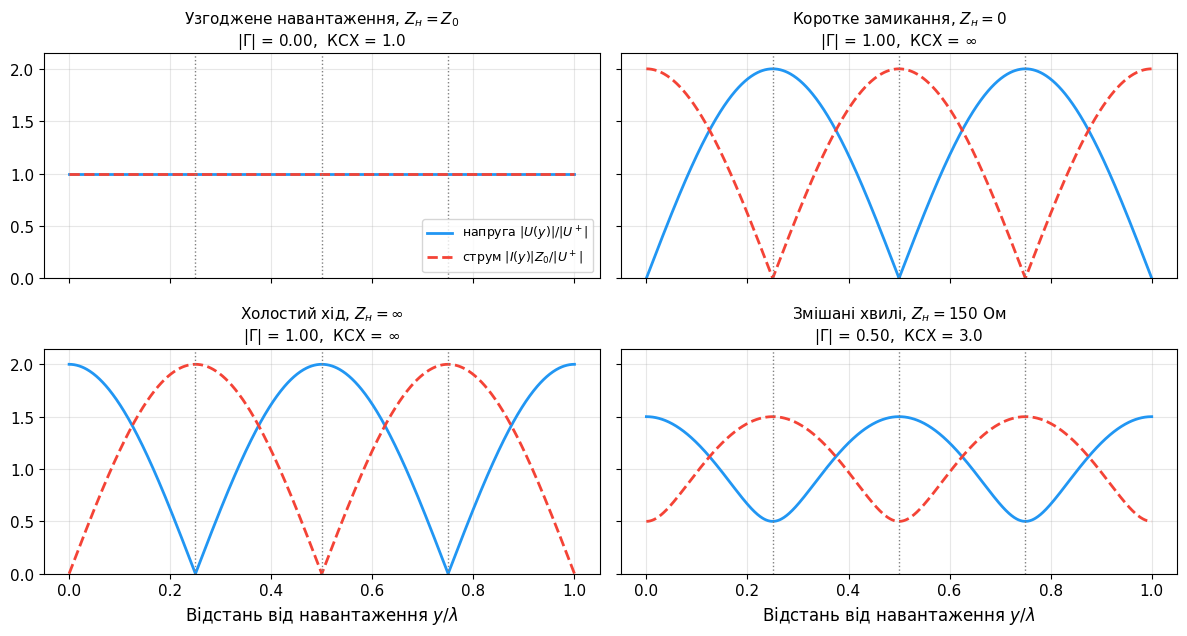

Вузли та пучності повторюються через λ/2; вузол напруги зсунутий від пучності на λ/4 і збігається з пучністю струму.


In [5]:
# Розподіл амплітуд напруги і струму вздовж лінії без втрат для різних навантажень
Z0_sw = 50.0
y_sw = np.linspace(0, 1.0, 801)                       # відстань від навантаження, y/λ
loads_sw = [('Узгоджене навантаження, $Z_н = Z_0$', 50.0),
            ('Коротке замикання, $Z_н = 0$', 0.0),
            ('Холостий хід, $Z_н = \\infty$', np.inf),
            ('Змішані хвилі, $Z_н = 150$ Ом', 150.0)]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex=True, sharey=True)
for ax, (title, ZL_sw) in zip(axes.flat, loads_sw):
    Gam_sw = 1.0 if np.isinf(ZL_sw) else (ZL_sw - Z0_sw) / (ZL_sw + Z0_sw)
    rot = np.exp(-2j * 2 * np.pi * y_sw)              # e^{-j2βy}
    ax.plot(y_sw, np.abs(1 + Gam_sw * rot), color='#2196F3', label='напруга $|U(y)|/|U^+|$')
    ax.plot(y_sw, np.abs(1 - Gam_sw * rot), color='#F44336', ls='--', label='струм $|I(y)|Z_0/|U^+|$')
    vswr_sw = '∞' if abs(Gam_sw) == 1 else f'{(1 + abs(Gam_sw)) / (1 - abs(Gam_sw)):.1f}'
    ax.set_title(f'{title}\n$|\\Gamma|$ = {abs(Gam_sw):.2f},  КСХ = {vswr_sw}', fontsize=11)
    for q in (0.25, 0.5, 0.75):
        ax.axvline(q, color='gray', ls=':', lw=1)
    ax.set_ylim(0, 2.15)
for ax in axes[1]:
    ax.set_xlabel('Відстань від навантаження $y/\\lambda$')
axes[0, 0].legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()
print('Вузли та пучності повторюються через λ/2; вузол напруги зсунутий від пучності на λ/4 і збігається з пучністю струму.')

---
### Відрізки лінії як реактивні елементи. Чвертьхвильовий трансформатор <a class="anchor" id="line-stubs"></a>

**Короткозамкнений відрізок** має вхідний опір $Z_{вх}=jZ_0\,\mathrm{tg}\,\beta l$, тобто поводиться як реактивний елемент, характер якого залежить від довжини:

| Довжина КЗ-відрізка | Характер | Еквівалент |
|---|---|---|
| $0 < l < \lambda/4$ | індуктивний | котушка $L_{екв} = \dfrac{Z_0\,\mathrm{tg}\,\beta l}{\omega}$ |
| $l = \lambda/4$ | $Z_{вх}\to\infty$ | паралельний коливальний контур |
| $\lambda/4 < l < \lambda/2$ | ємнісний | конденсатор |
| $l = \lambda/2$ | $Z_{вх}= 0$ | послідовний коливальний контур |

**Розімкнений відрізок** ($Z_{вх}=-jZ_0\,\mathrm{ctg}\,\beta l$) поводиться так само, але зі зсувом на $\lambda/4$: короткий розімкнений відрізок — це конденсатор. На частотах від сотень мегагерц, де зосереджені $L$ і $C$ стають надто малими, а їхні паразитні параметри — порівнянними з номінальними, саме відрізками ліній (**шлейфами**) реалізують реактивні елементи, резонатори та фільтри. Чвертьхвильовий КЗ-відрізок має на робочій частоті дуже великий вхідний опір, тому його використовують як **металевий ізолятор**, що тримає лінію, не шунтуючи її.

**Чвертьхвильовий трансформатор.** Відрізок довжиною $\lambda/4$ з хвильовим опором $Z_{т}$ перетворює активне навантаження $R_{н}$ на $Z_{вх}=Z_{т}^2/R_{н}$. Щоб узгодити навантаження з лінією $Z_0$, потрібно

$$Z_{т} = \sqrt{Z_0 R_{н}}$$

Наприклад, для узгодження 75-омної антени з 50-омним кабелем потрібен відрізок з $Z_{т}=\sqrt{50\cdot75}\approx61{,}2$ Ом. Узгодження точне лише на частоті, де довжина відрізка дорівнює $\lambda/4$; чим більше відношення $R_{н}/Z_0$, тим вужча смуга узгодження.

Побудуємо вхідний реактивний опір КЗ- і розімкненого відрізків залежно від довжини, а також залежність $|\Gamma_{вх}|$ від частоти для чвертьхвильового трансформатора:

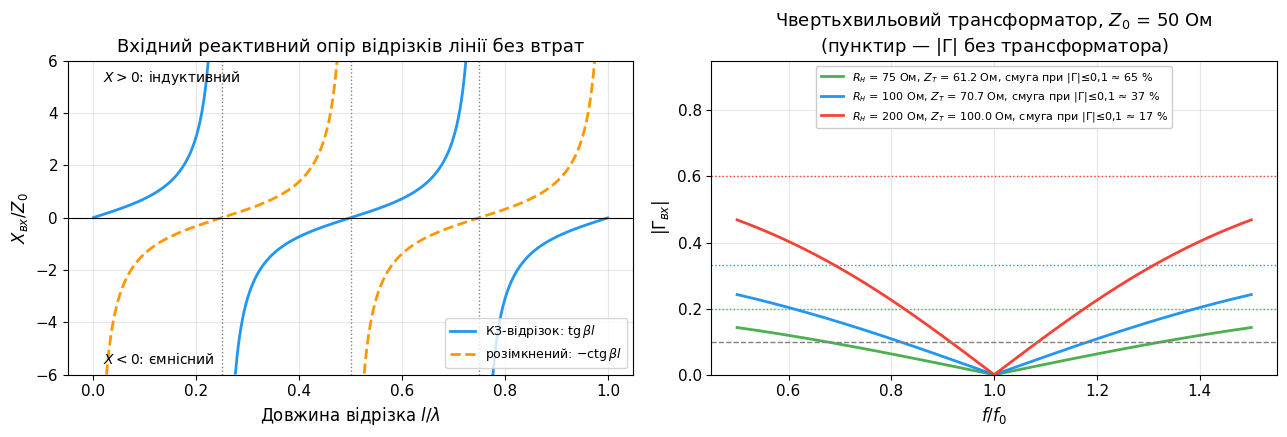

In [6]:
# Вхідний опір КЗ і розімкненого відрізків; смуга узгодження чвертьхвильового трансформатора
l_st = np.linspace(0.001, 0.999, 3000)               # довжина відрізка, l/λ
X_sc = np.tan(2 * np.pi * l_st)                      # X_вх / Z0, КЗ-відрізок
X_oc = -1 / np.tan(2 * np.pi * l_st)                 # X_вх / Z0, розімкнений відрізок
for arr in (X_sc, X_oc):
    arr[np.abs(arr) > 6] = np.nan                    # розриви поблизу резонансів

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(l_st, X_sc, color='#2196F3', label='КЗ-відрізок: $\\mathrm{tg}\\,\\beta l$')
ax1.plot(l_st, X_oc, color='#FF9800', ls='--', label='розімкнений: $-\\mathrm{ctg}\\,\\beta l$')
ax1.axhline(0, color='k', lw=0.8)
for q in (0.25, 0.5, 0.75):
    ax1.axvline(q, color='gray', ls=':', lw=1)
ax1.text(0.02, 5.2, '$X>0$: індуктивний', fontsize=10)
ax1.text(0.02, -5.6, '$X<0$: ємнісний', fontsize=10)
ax1.set_xlabel('Довжина відрізка $l/\\lambda$'); ax1.set_ylabel('$X_{вх}/Z_0$')
ax1.set_title('Вхідний реактивний опір відрізків лінії без втрат')
ax1.set_ylim(-6, 6); ax1.legend(loc='lower right', fontsize=9)

Z0_qw = 50.0
f_rel = np.linspace(0.5, 1.5, 1001)                  # f / f0
for RL_qw, color in [(75, '#4CAF50'), (100, '#2196F3'), (200, '#F44336')]:
    Zt = np.sqrt(Z0_qw * RL_qw)
    t = np.tan(np.pi / 2 * f_rel)                     # βl = π/2 на частоті f0
    Zin = Zt * (RL_qw + 1j * Zt * t) / (Zt + 1j * RL_qw * t)
    G = np.abs((Zin - Z0_qw) / (Zin + Z0_qw))
    band = f_rel[G <= 0.1]                            # |Γ| ≤ 0,1 (КСХ ≤ 1,22)
    ax2.plot(f_rel, G, color=color, label=f'$R_н$ = {RL_qw} Ом, $Z_т$ = {Zt:.1f} Ом, смуга при $|\\Gamma|$≤0,1 ≈ {100*(band.max()-band.min()):.0f} %')
    ax2.axhline(abs(RL_qw - Z0_qw) / (RL_qw + Z0_qw), color=color, ls=':', lw=1)
ax2.axhline(0.1, color='gray', ls='--', lw=1)
ax2.set_xlabel('$f/f_0$'); ax2.set_ylabel('$|\\Gamma_{вх}|$')
ax2.set_title('Чвертьхвильовий трансформатор, $Z_0$ = 50 Ом\n(пунктир — $|\\Gamma|$ без трансформатора)')
ax2.set_ylim(0, 0.95); ax2.legend(fontsize=8, loc='upper center', framealpha=1)
plt.tight_layout(); plt.show()

---
### 🔬 Інтерактивно: вхідний опір відрізка лінії <a class="anchor" id="line-zin-interactive"></a>

Оберіть хвильовий опір лінії, навантаження та довжину відрізка. Графік показує активну та реактивну складові вхідного опору як функції довжини $l/\lambda$; вертикальна лінія — обрана довжина. Зверніть увагу на повторення з періодом $\lambda/2$ та на інверсію опору на відстані $\lambda/4$.

In [7]:
# Інтерактивно: вхідний опір відрізка лінії без втрат залежно від довжини
def line_input_impedance(Z0=50.0, load='Довільне R + jX', R_load=100.0, X_load=0.0, l_lam=0.125):
    if load == 'Коротке замикання':
        Gam = -1.0 + 0j
    elif load == 'Холостий хід':
        Gam = 1.0 + 0j
    else:
        ZL = R_load + 1j * X_load
        Gam = (ZL - Z0) / (ZL + Z0)

    def z_in(l):
        g = Gam * np.exp(-4j * np.pi * l)             # Γ(l) = Γн·e^{-j2βl}
        with np.errstate(divide='ignore', invalid='ignore'):
            return Z0 * (1 + g) / (1 - g)

    l = np.linspace(0, 1, 2001)
    z = z_in(l)
    lim = 6 * Z0
    Re_z = np.where(np.abs(z) < lim, z.real, np.nan)
    Im_z = np.where(np.abs(z) < lim, z.imag, np.nan)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(l, Re_z, color='#2196F3', label='$R_{вх}$')
    ax.plot(l, Im_z, color='#F44336', ls='--', label='$X_{вх}$')
    ax.axhline(0, color='k', lw=0.8)
    ax.axhline(Z0, color='gray', ls=':', lw=1)
    ax.text(1.005, Z0, '$Z_0$', va='center')
    for q in (0.25, 0.5, 0.75):
        ax.axvline(q, color='gray', ls=':', lw=1)
    ax.axvline(l_lam, color='#4CAF50', lw=2, label=f'$l$ = {l_lam:.3f} λ')
    finite = np.abs(np.concatenate([Re_z[np.isfinite(Re_z)], Im_z[np.isfinite(Im_z)]]))
    ymax = min(lim, 1.15 * max(finite.max(), Z0))
    ax.set_xlim(0, 1); ax.set_ylim(-ymax, ymax)
    ax.set_xlabel('Довжина відрізка $l/\\lambda$'); ax.set_ylabel('Ом')
    vswr = '∞' if abs(Gam) > 0.9999 else f'{(1 + abs(Gam)) / (1 - abs(Gam)):.2f}'
    ax.set_title(f'$|\\Gamma_н|$ = {abs(Gam):.3f},  КСХ = {vswr}')
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

    z0 = z_in(np.array([l_lam]))[0]
    if not np.isfinite(z0) or abs(z0) > 1e6:
        print(f'l = {l_lam:.3f}λ: Z_вх → ∞ (паралельний резонанс)')
    else:
        kind = 'активний' if abs(z0.imag) < 1e-6 * max(1, abs(z0)) else ('індуктивний' if z0.imag > 0 else 'ємнісний')
        print(f'l = {l_lam:.3f}λ: Z_вх = {z0.real:.1f} {"+" if z0.imag >= 0 else "−"} j{abs(z0.imag):.1f} Ом  ({kind} характер)')

interact(line_input_impedance,
         Z0=widgets.FloatSlider(min=25, max=150, step=5, value=50, description='Z0 (Ом)'),
         load=widgets.Dropdown(options=['Довільне R + jX', 'Коротке замикання', 'Холостий хід'], value='Довільне R + jX', description='Навантаж.'),
         R_load=widgets.FloatSlider(min=0, max=500, step=5, value=100, description='Rн (Ом)'),
         X_load=widgets.FloatSlider(min=-300, max=300, step=5, value=0, description='Xн (Ом)'),
         l_lam=widgets.FloatSlider(min=0, max=1, step=0.005, value=0.125, readout_format='.3f', description='l/λ'));

interactive(children=(FloatSlider(value=50.0, description='Z0 (Ом)', max=150.0, min=25.0, step=5.0), Dropdown(…

---
### ⚙️ PySpice: відбиття імпульсу в лінії. Рефлектометрія <a class="anchor" id="line-tdr"></a>

Подамо короткий прямокутний імпульс від генератора з внутрішнім опором $R_г = Z_0 = 50$ Ом на лінію без втрат із затримкою $t_з = 10$ нс (приблизно 2 м коаксіального кабелю) і розглянемо напругу на **вході** лінії для різних навантажень. Генератор узгоджений з лінією, тому відбита від навантаження хвиля поглинається на вході й більше не відбивається.

- Падаюча хвиля має амплітуду $U^{+} = E\,\dfrac{Z_0}{R_г+Z_0} = 0{,}5\,E$.
- Через $2t_з = 20$ нс на вхід повертається відбитий імпульс з амплітудою $\Gamma_{н}U^{+}$: додатний для $R_{н}>Z_0$, від'ємний для $R_{н}<Z_0$, відсутній для узгодженого навантаження.

На цьому принципі ґрунтується **імпульсна рефлектометрія** (TDR — time-domain reflectometry): за часом затримки відбитого імпульсу визначають відстань до неоднорідності $d = v\,\Delta t/2$, а за його знаком і амплітудою — її характер (обрив, коротке замикання, пошкоджений роз'єм).

2026-10-09 11:15:07,872 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._init_ngspice - WARNING - Unsupported Ngspice version 42


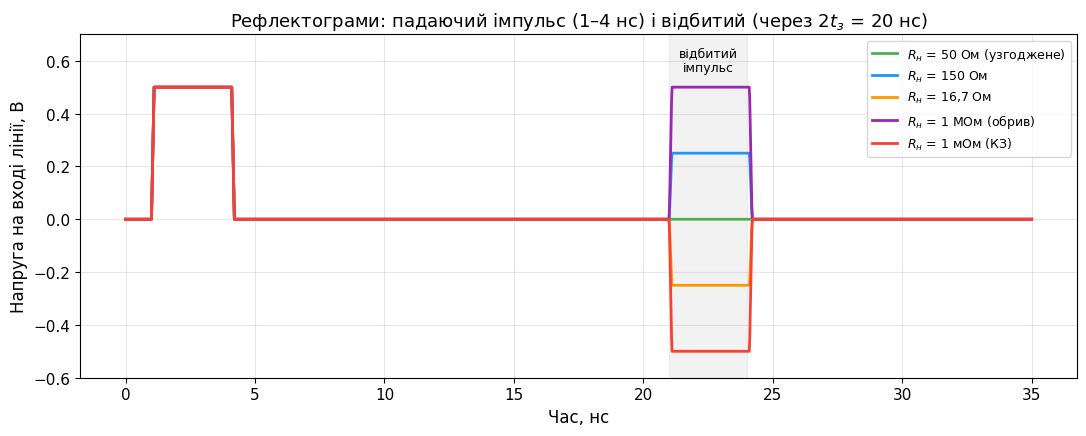

Навантаження                      Γн   теорія 0,5·Γн, В  PySpice, В
R_н = 50 Ом (узгоджене)        0.000              0.000       0.000
R_н = 150 Ом                   0.500              0.250       0.250
R_н = 16,7 Ом                 -0.500             -0.250      -0.250
R_н = 1 МОм (обрив)            1.000              0.500       0.500
R_н = 1 мОм (КЗ)              -1.000             -0.500      -0.500


In [8]:
# PySpice: напруга на вході лінії без втрат при різних навантаженнях (рефлектограми)
loads_tdr = [('$R_н$ = 50 Ом (узгоджене)', 50.0, '#4CAF50'),
             ('$R_н$ = 150 Ом', 150.0, '#2196F3'),
             ('$R_н$ = 16,7 Ом', 50.0 / 3, '#FF9800'),
             ('$R_н$ = 1 МОм (обрив)', 1e6, '#9C27B0'),
             ('$R_н$ = 1 мОм (КЗ)', 1e-3, '#F44336')]
Z0_tdr, td_tdr = 50.0, 10e-9

fig, ax = plt.subplots(figsize=(11, 4.5))
rows = []
for label, RL_tdr, color in loads_tdr:
    circuit = Circuit('Pulse reflection in a lossless line')
    circuit.PulseVoltageSource('g', 'gen', circuit.gnd, initial_value=0@u_V, pulsed_value=1@u_V,
                               delay_time=1@u_ns, rise_time=0.1@u_ns, fall_time=0.1@u_ns,
                               pulse_width=3@u_ns, period=100@u_ns)
    circuit.R('g', 'gen', 'inp', Z0_tdr@u_Ω)
    circuit.LosslessTransmissionLine('line', 'inp', circuit.gnd, 'load', circuit.gnd,
                                     impedance=Z0_tdr, time_delay=td_tdr)
    circuit.R('load', 'load', circuit.gnd, RL_tdr@u_Ω)
    analysis = circuit.simulator(temperature=25, nominal_temperature=25).transient(step_time=0.02@u_ns, end_time=35@u_ns)
    t_ns = np.array(analysis.time) * 1e9
    v_in = np.array(analysis['inp'])
    ax.plot(t_ns, v_in, color=color, label=label)
    echo = v_in[np.argmin(np.abs(t_ns - 22.5))]       # середина відбитого імпульсу
    rows.append((label.replace('$', ''), (RL_tdr - Z0_tdr) / (RL_tdr + Z0_tdr), echo))

ax.axvspan(21, 24, color='gray', alpha=0.1)
ax.text(22.5, 0.56, 'відбитий\nімпульс', ha='center', fontsize=9)
ax.set_xlabel('Час, нс'); ax.set_ylabel('Напруга на вході лінії, В')
ax.set_title('Рефлектограми: падаючий імпульс (1–4 нс) і відбитий (через $2t_з$ = 20 нс)')
ax.set_ylim(-0.6, 0.7); ax.legend(fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()

print(f'{"Навантаження":28s} {"Γн":>7s} {"теорія 0,5·Γн, В":>18s} {"PySpice, В":>11s}')
for name, G, echo in rows:
    print(f'{name:28s} {G:7.3f} {0.5 * G:18.3f} {echo:11.3f}')

---
### ⚡ Практичне застосування: Довга лінія

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Де на практиці враховують ефекти довгої лінії:**

| Застосування | Типовий $Z_0$ | Чому важливо |
|---------------|--------------|--------------|
| **Коаксіальний антенний фідер** | 50 / 75 Ом | Неузгодженість ($Z_L \neq Z_0$) дає відбиту хвилю і втрату потужності в антені |
| **Мікросмужкові лінії на платі (ВЧ/НВЧ)** | 50 Ом | Якщо довжина доріжки $\gtrsim \lambda/10$, її вже не можна вважати зосередженим провідником |
| **Кабельне телебачення** | 75 Ом | Узгодження знижує відбиття (примарні зображення) |
| **Цифрові шини (USB, HDMI, Ethernet)** | 90 / 100 / 120 Ом (диференціальні) | Неузгодженість спотворює фронти цифрових імпульсів |

> **Правило великого пальця:** лінію слід розглядати як «довгу», якщо її фізична довжина перевищує приблизно $\lambda/10$ на робочій частоті.


</div>


---
### ✅ Питання для самоперевірки: Довга лінія

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Коли лінію можна вважати «довгою»?</summary>

> **Відповідь:** Коли фізична довжина $l$ порівнянна або більша за довжину хвилі $\lambda = v_{ph}/f$. Практично: $l > \lambda/10$. Наприклад, для $f = 300$ МГц, $\lambda = 1$ м, то $l > 10$ см.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Що таке узгоджений режим і чому він важливий?</summary>

> **Відповідь:** $Z_L = Z_0$ — відбита хвиля відсутня ($\Gamma = 0$). Важливо для: максимальної передачі потужності, відсутності стоячих хвиль (КСХ = 1), уникнення перенапруг і резонансних явищ.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Що таке КСХ і які значення є допустимими?</summary>

> **Відповідь:** КСХ (Коефіцієнт Стоячої Хвилі) = $(1+|\Gamma|)/(1-|\Gamma|) \geq 1$. КСХ = 1 — ідеальне узгодження. Для антенних систем допустимо КСХ $\leq 1.5 \ldots 2.0$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чому короткозамкнений відрізок завдовжки $\lambda/4$ можна використовувати як ізолятор?</summary>

> **Відповідь:** Його вхідний опір $jZ_0\,\mathrm{tg}(\pi/2)\to\infty$: на робочій частоті відрізок поводиться як паралельний контур при резонансі й не шунтує лінію, до якої його приєднано, хоча на постійному струмі він є коротким замиканням.

</details>


---
### 📝 Задачі для самостійного розв'язання: Довга лінія


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Коаксіальний кабель має $L_0 = 250$ нГн/м, $C_0 = 100$ пФ/м, втратами можна знехтувати. Знайдіть хвильовий опір, фазову швидкість і довжину хвилі на 100 МГц. Чому дорівнює вхідний опір відрізка довжиною 1 м, навантаженого на $Z_н$?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $Z_х = \sqrt{L_0/C_0} = 50$ Ом; $v = 1/\sqrt{L_0C_0} = 2\cdot10^8$ м/с; $\lambda = v/f = 2$ м. Відрізок 1 м = $\lambda/2$ — він «повторює» навантаження: $Z_{вх} = Z_н$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Лінія з $Z_х = 50$ Ом навантажена на $Z_н = 75$ Ом. Знайдіть коефіцієнт відбиття, КСХ і частку відбитої потужності. Яким має бути хвильовий опір чвертьхвильового трансформатора для узгодження?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\Gamma = \dfrac{Z_н - Z_х}{Z_н + Z_х} = 0{,}2$; КСХ $= \dfrac{1 + |\Gamma|}{1 - |\Gamma|} = 1{,}5$; відбивається $|\Gamma|^2 = 4\,\%$ потужності. $Z_{тр} = \sqrt{Z_хZ_н} \approx 61{,}2$ Ом.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Для лінії з $R_0 = 0{,}1$ Ом/м, $L_0 = 250$ нГн/м, $C_0 = 100$ пФ/м визначте, якою має бути погонна провідність ізоляції $G_0$, щоб лінія не спотворювала сигнал.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Умова Хевісайда $R_0/L_0 = G_0/C_0$: $G_0 = R_0C_0/L_0 = 4\cdot10^{-5}$ См/м.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Рефлектометр подав у кабель з $v_{ф} = 2\cdot10^{8}$ м/с короткий імпульс. Через $\Delta t = 120$ нс повернувся відбитий імпульс протилежної полярності з амплітудою, майже рівною амплітуді падаючого. На якій відстані пошкодження і яке воно?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Відстань $d = v\,\Delta t/2 = 2\cdot10^{8}\cdot120\cdot10^{-9}/2 = 12$ м. Від'ємний відбитий імпульс з $|\Gamma|\approx1$ означає $\Gamma\approx-1$, тобто **коротке замикання** (для обриву імпульс був би тієї самої полярності).

</details>


---

### 📌 Підсумок теми <a class="anchor" id="topic-summary"></a>

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Величина | Формула |
|---|---|
| Хвильовий опір | $Z_0 = \sqrt{\dfrac{R'+j\omega L'}{G'+j\omega C'}}\;\approx\;\sqrt{L'/C'}$ |
| Коефіцієнт поширення | $\gamma = \alpha + j\beta = \sqrt{(R'+j\omega L')(G'+j\omega C')}$, $\;\beta = 2\pi/\lambda$ |
| Розв'язок для гармонічного сигналу | $\dot U(x) = \dot U^{+}e^{-\gamma x} + \dot U^{-}e^{\gamma x}$ |
| Коефіцієнт відбиття | $\Gamma_н = \dfrac{Z_н - Z_0}{Z_н + Z_0}$, $\;\Gamma(y) = \Gamma_н e^{-2\gamma y}$ |
| КСХ / КБХ | $\text{КСХ} = \dfrac{1+\vert\Gamma\vert}{1-\vert\Gamma\vert}$, $\;\text{КБХ} = 1/\text{КСХ}$ |
| Вхідний опір (без втрат) | $Z_{вх} = Z_0\,\dfrac{Z_н + jZ_0\,\mathrm{tg}\,\beta l}{Z_0 + jZ_н\,\mathrm{tg}\,\beta l}$ |
| Чвертьхвильовий трансформатор | $Z_{вх} = Z_т^2/Z_н$, $\;Z_т = \sqrt{Z_0 R_н}$ |
| Умова Хевісайда | $R'/L' = G'/C'$ |

**Головні висновки.** (1) Лінію вважають довгою, якщо її довжина перевищує $\approx\lambda/10$. (2) Неузгоджене навантаження породжує відбиту хвилю; режим лінії (біжуча, стояча чи змішана хвиля) визначається $|\Gamma|$. (3) Відрізок лінії трансформує опір навантаження з періодом $\lambda/2$; на відстані $\lambda/4$ опір інвертується, а КЗ- і розімкнені відрізки є реактивними елементами. (4) За часом і знаком відбитого імпульсу визначають місце та характер пошкодження кабелю.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 12. Перехідні процеси другого порядку](Тема_12_Перехідні_процеси_другого_порядку.ipynb) &nbsp;|&nbsp; [Тема 14. Радіотехнічні сигнали. Елементи функціонального аналізу](Тема_14_Радіотехнічні_сигнали.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
